In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import joblib

ЭТАП 1: Анализ данных (EDA)

Общая загрузка

In [2]:
# 1 Загрузить CSV и вывести первые 10 строк.
df = pd.read_csv('loan_data.csv')
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [3]:
# 2 Посмотреть .info() и .shape.
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

(45000, 14)

In [4]:
# 3 Проверить уникальные значения по object-признакам.
unique_home_ownership = df['person_home_ownership'].unique()
print("Уникальные значения для person_home_ownership:", unique_home_ownership)

Уникальные значения для person_home_ownership: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']


In [5]:
# 4 Оставить только выбранные 7 признаков + целевую переменную.
selected_columns = ['person_age', 'person_income', 'person_emp_exp', 'person_home_ownership',
                   'loan_amnt', 'loan_int_rate', 'credit_score', 'loan_status']
df = df[selected_columns]
print("Оставленные столбцы:", df.columns.tolist())

Оставленные столбцы: ['person_age', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_int_rate', 'credit_score', 'loan_status']


In [6]:
# 5 Сохранить облегчённый датасет в loan_clean.csv.
df.to_csv('loan_clean.csv', index=False)

In [7]:
# 6 Посчитать средний доход, возраст, стаж.
income = round(df['person_income'].mean(), 2)
age = round(df['person_age'].mean(), 2)
exp = round(df['person_emp_exp'].mean(), 2)
print(f'Средний доход: {income}, Средний возраст: {age}, Средний стаж: {exp}')

Средний доход: 80319.05, Средний возраст: 27.76, Средний стаж: 5.41


In [8]:
# 7 Сколько заемщиков имеют кредитный балл < 600?
credit_score = (df['credit_score'] < 600).sum()
print(f'{credit_score} заемщиков имеют кредитный балл < 600.')

10828 заемщиков имеют кредитный балл < 600.


In [9]:
# 8 Распределение по типу жилья (person_home_ownership) — value_counts().
print(df['person_home_ownership'].value_counts())

person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64


In [10]:
# 9 Средняя ставка и сумма кредита по группам loan_status.
print(df.groupby('loan_status')[['loan_int_rate', 'loan_amnt']].mean().round())

             loan_int_rate  loan_amnt
loan_status                          
0                     10.0     9220.0
1                     13.0    10856.0


In [11]:
# 10 Кол-во заявителей с опытом работы 0 лет.
print('Кол-во заявителей с опытом работы 0 лет:', (df['person_emp_exp'] == 0).sum())

Кол-во заявителей с опытом работы 0 лет: 9566


In [12]:
# 11 Сколько заемщиков берут кредит более чем на половину дохода (loan_percent_income > 0.5)?
df['loan_percent_income'] = df['loan_amnt'] / df['person_income']
print((df['loan_percent_income'] > 0.5).sum(), 'заемщиков берут кредит более чем на половину дохода')

60 заемщиков берут кредит более чем на половину дохода


In [13]:
# 12 Группировка по person_home_ownership — средний loan_int_rate.
print((df.groupby('person_home_ownership')['loan_int_rate']).mean().round())

person_home_ownership
MORTGAGE    11.0
OTHER       12.0
OWN         11.0
RENT        11.0
Name: loan_int_rate, dtype: float64


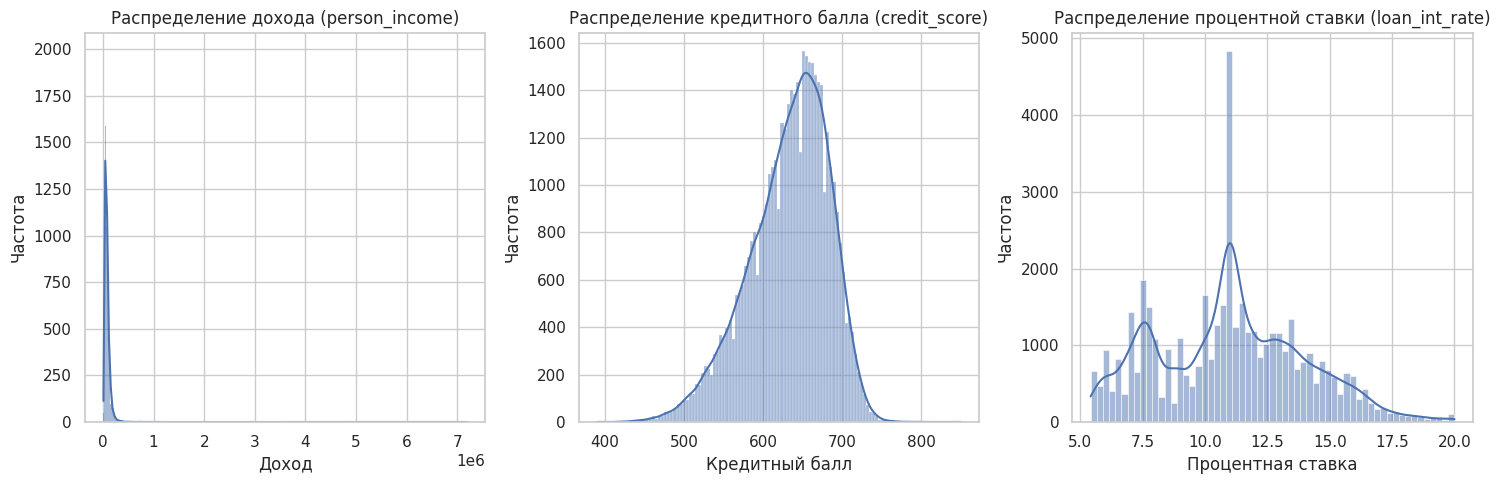

In [14]:
# 13 Hist / distplot по:
    # person_income
    # credit_score
    # loan_int_rate
# Установка стиля для графиков
sns.set(style="whitegrid")

# Создание гистограмм
plt.figure(figsize=(15, 5))

# Гистограмма для person_income
plt.subplot(1, 3, 1)
sns.histplot(df['person_income'], kde=True)
plt.title('Распределение дохода (person_income)')
plt.xlabel('Доход')
plt.ylabel('Частота')

# Гистограмма для credit_score
plt.subplot(1, 3, 2)
sns.histplot(df['credit_score'], kde=True)
plt.title('Распределение кредитного балла (credit_score)')
plt.xlabel('Кредитный балл')
plt.ylabel('Частота')

# Гистограмма для loan_int_rate
plt.subplot(1, 3, 3)
sns.histplot(df['loan_int_rate'], kde=True)
plt.title('Распределение процентной ставки (loan_int_rate)')
plt.xlabel('Процентная ставка')
plt.ylabel('Частота')

# Настройка отображения
plt.tight_layout()
plt.show()

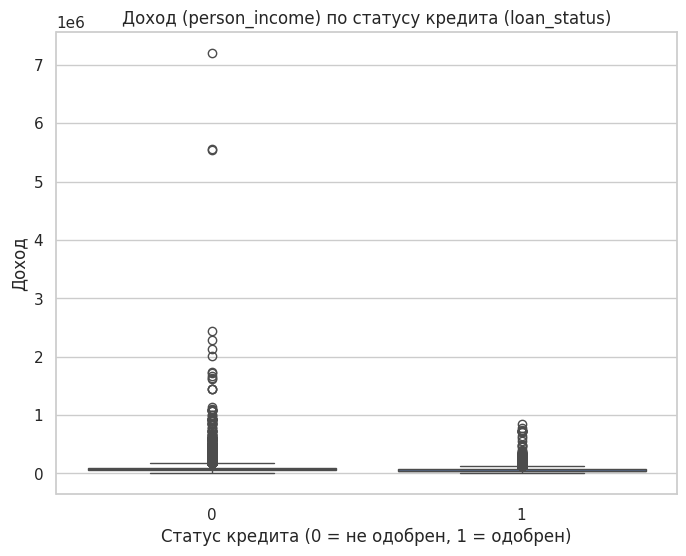

In [15]:
# 14 Boxplot: loan_status vs person_income
# Установка стиля
sns.set(style="whitegrid")

# Построение boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.title('Доход (person_income) по статусу кредита (loan_status)')
plt.xlabel('Статус кредита (0 = не одобрен, 1 = одобрен)')
plt.ylabel('Доход')
plt.show()

<Figure size 1000x600 with 0 Axes>

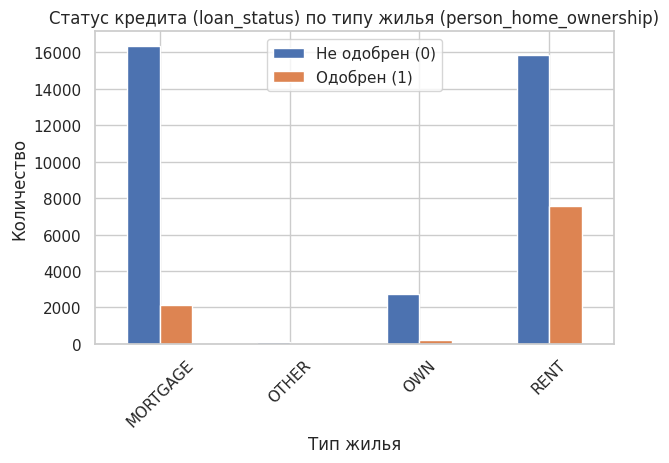

In [16]:
# 15 Barplot: loan_status vs person_home_ownership
# Установка стиля
sns.set(style="whitegrid")

# Подсчёт количества по категориям
plot_data = df.groupby(['person_home_ownership', 'loan_status']).size().unstack()

# Построение barplot
plt.figure(figsize=(10, 6))
plot_data.plot(kind='bar', stacked=False)
plt.title('Статус кредита (loan_status) по типу жилья (person_home_ownership)')
plt.xlabel('Тип жилья')
plt.ylabel('Количество')
plt.legend(['Не одобрен (0)', 'Одобрен (1)'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

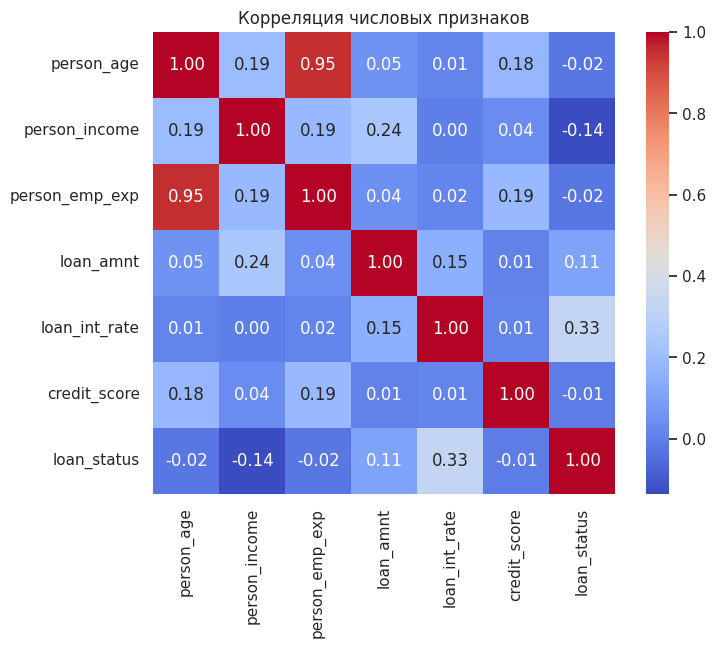

In [17]:
# 16 Heatmap корреляций числовых признаков
# Выбор числовых признаков
numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'credit_score', 'loan_status']

# Вычисление корреляционной матрицы
corr_matrix = df[numeric_cols].corr()

# Построение heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Корреляция числовых признаков')
plt.show()

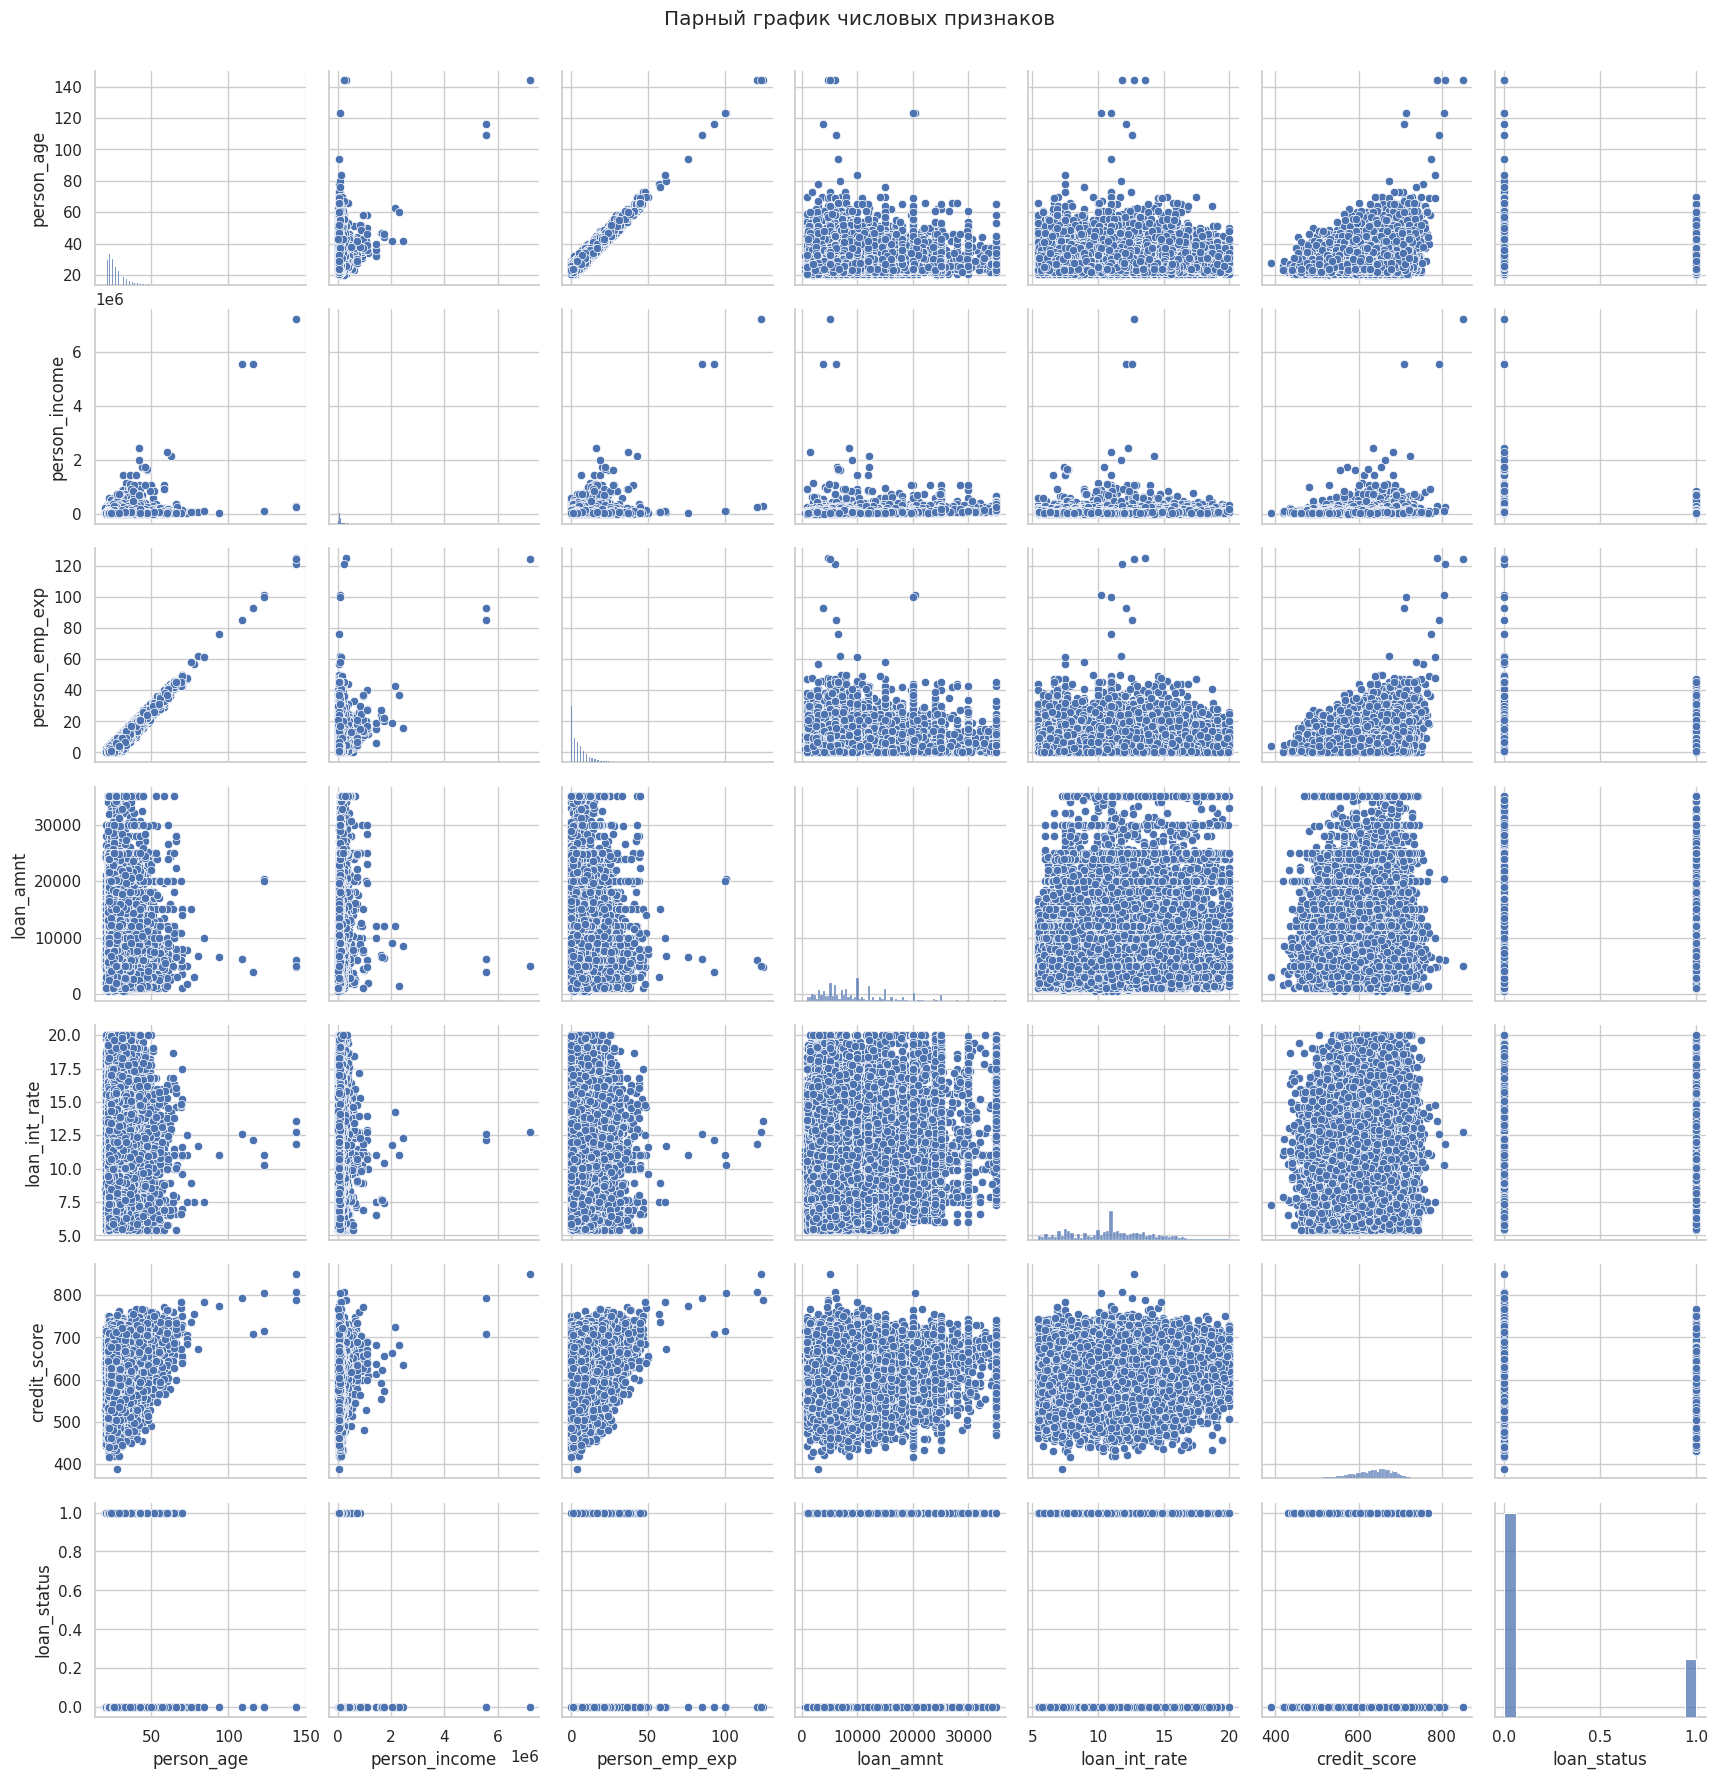

In [18]:
# 17 Pairplot по числовым признакам
# Выбор числовых признаков
numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'credit_score', 'loan_status']

# Построение pairplot
sns.pairplot(df[numeric_cols])
plt.suptitle('Парный график числовых признаков', y=1.02)
plt.show()

ЭТАП 2: Предобработка

In [19]:
# 18 Проверка пропущенных значений и заполнение (или удаление).
df.isnull().sum()

,0
person_age,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_int_rate,0
credit_score,0
loan_status,0
loan_percent_income,0


In [20]:
# 19 Кодировка категориальных признаков (OneHotEncoder или LabelEncoder):
    # person_home_ownership
df = pd.get_dummies(df, columns=['person_home_ownership'], drop_first=True).astype(int)

In [21]:
# 20 Масштабирование числовых признаков (StandardScaler).
scaler = StandardScaler()
new_df = df.drop(columns=['loan_status'])
scaled_data = scaler.fit_transform(new_df)

In [22]:
scaled_data

array([[-0.95353824, -0.10408961, -0.89228413, ..., -0.05105661,
        -0.26491513,  0.95893146],
       [-1.11896309, -0.84600467, -0.89228413, ..., -0.05105661,
         3.77479378, -1.0428274 ],
       [-0.45726369, -0.84406489, -0.3975175 , ..., -0.05105661,
        -0.26491513, -1.0428274 ],
       ...,
       [ 0.8661351 , -0.29068126,  0.26217134, ..., -0.05105661,
        -0.26491513,  0.95893146],
       [ 0.2044357 , -0.58634807, -0.23259529, ..., -0.05105661,
        -0.26491513,  0.95893146],
       [-0.62268854, -0.35699428, -0.72736192, ..., -0.05105661,
        -0.26491513,  0.95893146]])

In [23]:
# 21 Разделение X и y (где y = loan_status).
x = scaled_data
y = df['loan_status']

In [24]:
# 22 train/test split (80/20).
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

ЭТАП 3: Логистическая регрессия

In [25]:
# 23 Обучить LogisticRegression() на обучающей выборке.
model_log = LogisticRegression()
model_tree = DecisionTreeClassifier()

In [26]:
model_log.fit(x_train, y_train)

LogisticRegression()

In [27]:
model_tree.fit(x_train, y_train)

DecisionTreeClassifier()

In [28]:
# 24 Предсказать на тестовой выборке.
y_pred_log = model_log.predict(x_test)
y_pred_tree = model_tree.predict(x_test)

In [29]:
# 25 Посчитать метрики:
    # Accuracy
    # Precision, Recall
    # F1-score
    # Confusion Matrix (график)
    # ROC AUC (и построить кривую)
print(f'Model log: {accuracy_score(y_test, y_pred_log)}')
print(f'Model tree: {accuracy_score(y_test, y_pred_tree)}')

Model log: 0.8314444444444444
Model tree: 0.8414444444444444


In [30]:
# 27 Сохранить модель (joblib или pickle).
joblib.dump(model_tree, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [31]:
df.columns

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'credit_score', 'loan_status', 'loan_percent_income',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT'],
      dtype='object')

In [32]:
li = []
for i in df:
  subword = 'person_home_ownership_'
  if subword in i:
    li.append(i[len(subword):])
print(li)

['OTHER', 'OWN', 'RENT']
